In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import PromptTemplate
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict
from dotenv import load_dotenv

In [ ]:
load_dotenv()

llm = ChatHuggingFace(
    llm=HuggingFaceEndpoint(
        repo_id="Qwen/Qwen3.8-2.4T-A95B",
    )
)

prompt = PromptTemplate(
    template="Answer the following question : \n {ques}",
    input_variables=["ques"]
)



c:\Users\saura\OneDrive\Desktop\AI Engineering\LangGraph\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class QAState(TypedDict):
    ques : str
    ans : str

In [4]:
def get_ans(state : QAState) -> QAState:
    ques = state["ques"]
    
    chain = prompt | llm 
    ans = chain.invoke({"ques":ques})
    
    state["ans"] = ans.content
    
    return state

In [5]:
graph = StateGraph(QAState)

graph.add_node("get_ans",get_ans)

graph.add_edge(START,"get_ans")
graph.add_edge("get_ans",END)

workflow = graph.compile()

In [6]:
initial_state = {"ques":"What is the distance between earth and moon?"}
final_state = workflow.invoke(initial_state)

print(final_state)

{'ques': 'What is the distance between earth and moon?', 'ans': 'The average distance between Earth and the Moon is about **384,400 kilometers** (**238,855 miles**).\n\nIt varies because the Moon’s orbit is elliptical:\n\n- **Closest approach (perigee):** about **363,300 km**\n- **Farthest distance (apogee):** about **405,500 km**'}


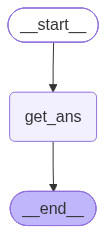

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())